# Associative Classification of Lower or Uncertain Self-Perceived Academic Success

## Evidence from a global higher-education ChatGPT survey

**Dataset:** Higher Education Students’ Evolving Perceptions of ChatGPT: Global Survey Data from the Academic Year 2024–2025  
**Source:** Mendeley Data, version 2, DOI [10.17632/nv2343nwsb.2](https://doi.org/10.17632/nv2343nwsb.2), CC BY 4.0  
**Observed data:** 22,963 anonymous survey responses from 120 countries and territories; this is not synthetic data.

**Target:** Q35a, “I am successful in my studies.”

- Positive class (1): responses 1–3, a support-oriented modelling choice representing **lower or uncertain self-perceived success**.
- Negative class (0): responses 4–5, representing **higher self-perceived success**.
- This is a subjective survey response, not an objective grade, diagnosis or proof of academic failure.

**Application objective:** compare five complementary supervised-learning families and identify response patterns associated with the positive class. Asking Q35a directly is simpler and more transparent than operational prediction; any prospective support application would require a shorter input design, an objective outcome and external validation.

The test set is locked after one split. Model and hyperparameter selection use training cross-validation only.


## 1. Dataset Understanding and Literature Review

### 1.1 Dataset and prediction objective

The survey was administered between October 2024 and February 2025 in seven languages using convenience sampling. It records sociodemographic context, ChatGPT use, perceived capabilities, regulation and ethics, satisfaction, study outcomes, skills, emotions and study information. The data contain numeric, ordinal, binary and nominal variables, together with realistic missingness, noisy entries and high dimensionality.

Q35a is suitable because it retains more than 15,000 labelled observations and has two usable classes. Candidate predictors are restricted to Q1–Q34; Q35b–Q40 are excluded to reduce direct same-section proxying. Institution, free text, citizenship, study country, gender, age and survey language are excluded from model inputs for privacy, cardinality or fairness reasons. Gender, age and survey language are retained separately for subgroup auditing.

### 1.2 Recent related evidence

| Study | Data and method | Main finding relevant here | Limitation informing this work |
|---|---|---|---|
| [Ravšelj et al. (2025), PLOS ONE](https://doi.org/10.1371/journal.pone.0315011) | Large global cross-sectional student survey; descriptive analysis and ordinal regressions. | ChatGPT perceptions and use differ across tasks and student contexts. | Earlier survey wave, convenience sampling and self-report prevent causal or representative claims. |
| [Yağcı (2022), Smart Learning Environments](https://doi.org/10.1186/s40561-022-00192-z) | 1,854 Turkish-language students; six classical ML classifiers using midterm, department and faculty data. | Several model families can identify patterns associated with final-exam categories. | One course and a strong prior-grade predictor limit generalisation. |
| [Li et al. (2022), Complex & Intelligent Systems](https://doi.org/10.1007/s40747-022-00731-8) | Multi-source campus behaviour and demographics; LSTM and 2D-CNN achievement model. | Combining heterogeneous behavioural sources can improve achievement classification. | Institution-specific digital traces and objective outcomes differ from a cross-national perception survey. |
| [Youssef et al. (2024)](https://doi.org/10.1016/j.caeai.2024.100316) | 353 UAE university questionnaires; cross-sectional PLS-SEM. | ChatGPT use was associated with engagement, critical thinking and reported achievement. | Small local self-report sample and cross-sectional design do not establish effects. |
| [Smerdon (2024)](https://doi.org/10.1016/j.caeai.2024.100288) | Mixed-method analysis of permitted AI use in an undergraduate research assignment. | AI adopters did not score higher, and prior achievement influenced adoption. | One assignment and voluntary tool use constrain broader inference. |
| [Baek, Tate and Warschauer (2024)](https://doi.org/10.1016/j.caeai.2024.100294) | 1,001 US college students; regressions plus thematic analysis. | Use differed by demographic, study and institutional-policy context, raising equity concerns. | US panel, self-report and cross-sectional data limit transferability. |

### 1.3 Gap and contribution

ChatGPT studies commonly use regional or cross-sectional explanatory models, while academic-performance prediction often relies on grades or platform logs. This analysis instead performs a leakage-controlled comparison of five complementary model families on a large cross-national survey, applies supervised feature selection, and evaluates explanation and subgroup performance. The contribution is a reproducible associative classification benchmark—not evidence that ChatGPT use causes success and not a validated early-warning system.


In [ ]:
# Install only the workbook reader if it is absent from the current kernel.
%pip install -q openpyxl


In [ ]:
from pathlib import Path
import hashlib
import json
import platform
import re
import shutil
import urllib.request
import warnings
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
SEARCH_ITERATIONS = 6

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1'}


In [ ]:
DATASET_TITLE = "Higher Education Students’ Evolving Perceptions of ChatGPT"
DATASET_DOI = "10.17632/nv2343nwsb.2"
DATA_ZIP_URL = "https://data.mendeley.com/public-api/zip/nv2343nwsb/download/2"
EXPECTED_ZIP_SHA256 = "5696c4d92ed0b6324721552a71425f38b0d7f3415314e860ad3fb4992122db62"

DATA_DIR = Path("q1_data")
ZIP_PATH = DATA_DIR / "mendeley_nv2343nwsb_v2.zip"
ARTIFACT_DIR = Path("q1_model_package")

TARGET_SOURCE = "Q35a"
TARGET_NAME = "lower_or_uncertain_self_perceived_success"

TASK_COLUMNS = [f"Q18{suffix}" for suffix in "abcdefghijkl"]
CAPABILITY_COLUMNS = [f"Q19{suffix}" for suffix in "abcdefghij"]
ETHICAL_COLUMNS = [f"Q22{suffix}" for suffix in "abcdefghij"]
POSITIVE_EMOTIONS = ["Q32b", "Q32e", "Q32g", "Q32h", "Q32i", "Q32l", "Q32m"]
NEGATIVE_EMOTIONS = ["Q32a", "Q32c", "Q32d", "Q32f", "Q32j", "Q32n", "Q32o"]

ENGINEERED_FEATURES = [
    "chatgpt_task_breadth_rate",
    "capability_mean",
    "ethical_concern_mean",
    "emotion_balance",
]

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def question_number(name):
    match = re.fullmatch(r"Q([0-9]+)[a-z]?", str(name))
    return int(match.group(1)) if match else None

def row_mean(frame, columns, minimum_answered):
    block = frame[columns].apply(pd.to_numeric, errors="coerce")
    answered = block.notna().sum(axis=1)
    return block.mean(axis=1, skipna=True).where(answered >= minimum_answered)

def engineer_features(frame):
    result = frame.copy()
    task_block = result[TASK_COLUMNS].apply(pd.to_numeric, errors="coerce")
    task_answered = task_block.notna().sum(axis=1)
    result["chatgpt_task_breadth_rate"] = (
        task_block.ge(3).sum(axis=1)
        .div(task_answered.replace(0, np.nan))
        .where(task_answered >= 10)
    )
    result["capability_mean"] = row_mean(result, CAPABILITY_COLUMNS, minimum_answered=8)
    result["ethical_concern_mean"] = row_mean(result, ETHICAL_COLUMNS, minimum_answered=8)
    result["emotion_balance"] = (
        row_mean(result, POSITIVE_EMOTIONS, minimum_answered=6)
        - row_mean(result, NEGATIVE_EMOTIONS, minimum_answered=6)
    )
    return result


In [ ]:
import subprocess

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    print("Downloading Mendeley Data version 2 using curl...")

    subprocess.run(
        [
            "curl",
            "-L",
            "--fail",
            "--show-error",
            "--retry", "3",
            "--retry-delay", "2",
            "--connect-timeout", "30",
            "--max-time", "600",
            "-A", "Mozilla/5.0",
            "-H", "Referer: https://data.mendeley.com/",
            "-o", str(ZIP_PATH),
            DATA_ZIP_URL,
        ],
        check=True,
    )

dataset_zip_sha256 = sha256_file(ZIP_PATH)

if dataset_zip_sha256 != EXPECTED_ZIP_SHA256:
    ZIP_PATH.unlink(missing_ok=True)

    raise ValueError(
        "Dataset checksum validation failed.\n"
        f"Expected: {EXPECTED_ZIP_SHA256}\n"
        f"Actual:   {dataset_zip_sha256}"
    )

print("Download and checksum validation successful.")

Download and checksum validation successful.


In [ ]:
# ------------------------------------------------------------
# Extract ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    corrupted_file = archive.testzip()

    if corrupted_file is not None:
        raise zipfile.BadZipFile(
            f"Corrupted file detected inside archive: {corrupted_file}"
        )

    archive.extractall(DATA_DIR)

print("Dataset archive extracted successfully.")


# ------------------------------------------------------------
# Find the Excel workbook
# ------------------------------------------------------------

xlsx_candidates = [
    path
    for path in DATA_DIR.rglob("final dataset.xlsx")
    if not path.name.startswith("~$")
]

if len(xlsx_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one file named 'final dataset.xlsx', "
        f"but found {len(xlsx_candidates)}.\n"
        + "\n".join(str(path) for path in xlsx_candidates)
    )

XLSX_PATH = xlsx_candidates[0]


# ------------------------------------------------------------
# Load the dataset and define df_raw
# ------------------------------------------------------------

df_raw = pd.read_excel(
    XLSX_PATH,
    sheet_name="final dataset",
    engine="openpyxl",
)


# ------------------------------------------------------------
# Validate loaded dataset
# ------------------------------------------------------------

print("Workbook:", XLSX_PATH)
print("ZIP SHA-256:", dataset_zip_sha256)
print("Raw shape:", df_raw.shape)

assert df_raw.shape == (22963, 180), (
    "Unexpected dataset shape. "
    f"Expected (22963, 180), but received {df_raw.shape}."
)
print("df_raw has been successfully defined.")

Dataset archive extracted successfully.
Workbook: q1_data/Higher Education Students’ Evolving Perceptions of/final dataset.xlsx
ZIP SHA-256: 5696c4d92ed0b6324721552a71425f38b0d7f3415314e860ad3fb4992122db62
Raw shape: (22963, 180)
df_raw has been successfully defined.


In [ ]:
## 1.5 Compact raw-data audit
raw_duplicate_count = int(df_raw.duplicated().sum())
raw_missing_rate = float(df_raw.isna().mean().mean())
raw_rows_with_missing = int(df_raw.isna().any(axis=1).sum())

raw_audit = pd.Series({
    "Rows": len(df_raw),
    "Columns": df_raw.shape[1],
    "Exact duplicate excess rows": raw_duplicate_count,
    "Overall missing-cell rate": raw_missing_rate,
    "Rows containing missing values": raw_rows_with_missing,
    "Q35a non-missing": int(df_raw[TARGET_SOURCE].notna().sum()),
    "Q5 institution unique values": int(df_raw["Q5"].nunique(dropna=True)),
    "Q13f_text missing rate": float(df_raw["Q13f_text"].isna().mean()),
})
display(raw_audit.to_frame("Value"))

display(
    df_raw[TARGET_SOURCE]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Q35a response")
    .to_frame("Count")
)

display(df_raw["source"].value_counts().rename_axis("Survey language").to_frame("Count"))

,Value
Rows,22963.000000
Columns,180.000000
Exact duplicate excess rows,127.000000
Overall missing-cell rate,0.230413
Rows containing missing values,22403.000000
Q35a non-missing,17427.000000
Q5 institution unique values,8662.000000
Q13f_text missing rate,0.946348


,Count
Q35a response,
1.0,321
2.0,842
3.0,5293
4.0,8461
5.0,2510
NaN,5536


,Count
Survey language,
EN,13836
ES,3744
AR,2487
TR,1332
IT,1256
JP,195
HE,113


## 2. Data Analysis and Feature Engineering

### 2.1 Data-quality policy

- Exact duplicate records are removed before splitting.
- Q35a is never imputed; rows without a target are excluded.
- Questionnaire codes are validated against their documented ranges.
- Age strings containing a clear age are parsed; birth-year-like values outside 18–100 become missing rather than being guessed.
- Plausible extreme ages are retained for EDA and fairness auditing; age is excluded from prediction rather than clipped.
- Q13a remains an explicit ChatGPT-use branch indicator; routed downstream blanks are not treated as zero.
- Predictor missingness is handled inside each training fold. Missing indicators expose absence to the model but cannot prove whether it came from routing, nonresponse or attrition.
- High-cardinality institution and free-text fields are excluded rather than encoded.

In [ ]:
## 2.2 Remove duplicates, validate questionnaire codes, and create the target
df = df_raw.drop_duplicates().copy()

# Parse the two noisy text ages while rejecting birth-year-like values.
age_text = df["Q3"].astype("string")
age_numeric_direct = pd.to_numeric(age_text, errors="coerce")
age_digits = pd.to_numeric(
    age_text.str.extract(r"([0-9]{2,4})", expand=False),
    errors="coerce",
)
parsed_age = age_numeric_direct.fillna(age_digits)
recovered_text_ages = int((age_numeric_direct.isna() & parsed_age.notna()).sum())
invalid_age_mask = parsed_age.notna() & ~parsed_age.between(18, 100)
invalid_age_count = int(invalid_age_mask.sum())
df["Q3"] = parsed_age.mask(invalid_age_mask)

# Coerce all coded questions through Q35 to numeric, excluding genuine text fields.
for column in df.columns:
    number = question_number(column)
    if number is not None and 2 <= number <= 35 and column not in {"Q3", "Q5", "Q13f_text"}:
        df[column] = pd.to_numeric(df[column], errors="coerce")

range_rules = {
    "Q2": (1, 4),
    "Q6": (1, 2),
    "Q7": (1, 2),
    "Q8": (1, 3),
    "Q9": (1, 2),
    "Q10": (1, 4),
    "Q11": (1, 3),
    "Q12": (1, 5),
    "Q14": (1, 3),
    "Q15": (1, 5),
    "Q16": (1, 5),
    "Q17": (1, 4),
    "Q20": (1, 3),
    "Q33": (1, 5),
    "Q34": (1, 3),
    TARGET_SOURCE: (1, 5),
}
range_rules.update({f"Q13{s}": (0, 1) for s in "abcdef"})
for section in [18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]:
    for column in [c for c in df.columns if question_number(c) == section]:
        range_rules[column] = (1, 5)

invalid_response_counts = {}
for column, (lower, upper) in range_rules.items():
    invalid = df[column].notna() & ~df[column].between(lower, upper)
    invalid_response_counts[column] = int(invalid.sum())
    df.loc[invalid, column] = np.nan

target_missing_count = int(df[TARGET_SOURCE].isna().sum())
df = df[df[TARGET_SOURCE].notna()].copy()
df[TARGET_NAME] = (df[TARGET_SOURCE] <= 3).astype("int8")

# Identify statistical age outliers after domain validation. They remain plausible ages,
# so they are retained for EDA/fairness auditing; age is excluded from prediction.
age_q1, age_q3 = df["Q3"].quantile([0.25, 0.75])
age_iqr = age_q3 - age_q1
age_lower_fence = max(18, age_q1 - 1.5 * age_iqr)
age_upper_fence = min(100, age_q3 + 1.5 * age_iqr)
plausible_age_outlier_count = int(
    (df["Q3"].notna() & ~df["Q3"].between(age_lower_fence, age_upper_fence)).sum()
)

target_distribution = pd.DataFrame({
    "Count": df[TARGET_NAME].value_counts().sort_index(),
    "Percentage": df[TARGET_NAME].value_counts(normalize=True).sort_index().mul(100),
}).rename(index={0: "Higher self-perceived success", 1: "Lower/uncertain self-perceived success"})

display(target_distribution)
print({
    "cleaned_labelled_rows": len(df),
    "recovered_text_ages": recovered_text_ages,
    "invalid_ages_set_missing": invalid_age_count,
    "plausible_age_outliers_retained": plausible_age_outlier_count,
    "age_iqr_fences": (float(age_lower_fence), float(age_upper_fence)),
    "invalid_coded_responses_set_missing": sum(invalid_response_counts.values()),
    "rows_removed_for_missing_target": target_missing_count,
})
assert len(df) == 17426
assert df[TARGET_NAME].value_counts().to_dict() == {0: 10971, 1: 6455}
assert len(df) >= 15000

,Count,Percentage
lower_or_uncertain_self_perceived_success,,
Higher self-perceived success,10971,62.957649
Lower/uncertain self-perceived success,6455,37.042351


{'cleaned_labelled_rows': 17426, 'recovered_text_ages': 2, 'invalid_ages_set_missing': 2, 'plausible_age_outliers_retained': 1490, 'age_iqr_fences': (18.0, 30.0), 'invalid_coded_responses_set_missing': 0, 'rows_removed_for_missing_target': 5410}


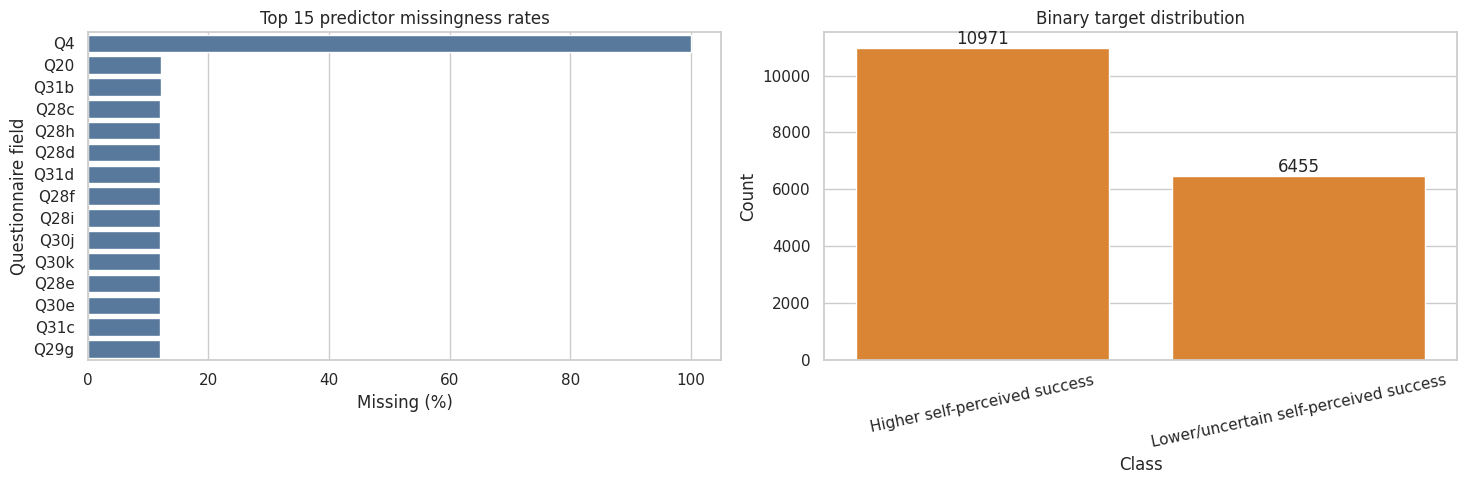

,Data-quality item,Count
0,Raw exact duplicate excess rows,127
1,Rows retained after duplicate and target cleaning,17426
2,Invalid ages set to missing,2
3,Plausible age values outside IQR fences (retai...,1490
4,Target missing rows excluded,5410


In [ ]:
## 2.3 Missingness, duplicates and target visualization
candidate_q1_q34 = [
    column for column in df.columns
    if question_number(column) is not None and question_number(column) <= 34
]
top_missing = (
    df[candidate_q1_q34]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=top_missing.values, y=top_missing.index, ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 15 predictor missingness rates")
axes[0].set_xlabel("Missing (%)")
axes[0].set_ylabel("Questionnaire field")

plot_target = target_distribution.reset_index(names="Class")
sns.barplot(data=plot_target, x="Class", y="Count", ax=axes[1], color="#F58518")
axes[1].set_title("Binary target distribution")
axes[1].tick_params(axis="x", rotation=12)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "Data-quality item": [
        "Raw exact duplicate excess rows",
        "Rows retained after duplicate and target cleaning",
        "Invalid ages set to missing",
        "Plausible age values outside IQR fences (retained)",
        "Target missing rows excluded",
    ],
    "Count": [
        raw_duplicate_count,
        len(df),
        invalid_age_count,
        plausible_age_outlier_count,
        target_missing_count,
    ],
}))

In [ ]:
## 2.4 Construct four row-wise composite features
df_features = engineer_features(df)

component_columns = set(
    TASK_COLUMNS
    + CAPABILITY_COLUMNS
    + ETHICAL_COLUMNS
    + POSITIVE_EMOTIONS
    + NEGATIVE_EMOTIONS
)
excluded_from_model = {"Q1", "Q2", "Q3", "Q4", "Q5", "Q13f_text", TARGET_SOURCE}

raw_predictor_columns = [
    column for column in df_features.columns
    if question_number(column) is not None and question_number(column) <= 34
]
MODEL_FEATURE_COLUMNS = [
    column for column in raw_predictor_columns
    if column not in excluded_from_model and column not in component_columns
] + ENGINEERED_FEATURES

X = df_features[MODEL_FEATURE_COLUMNS].copy()
y = df_features[TARGET_NAME].copy()

NOMINAL_COLUMNS = [
    column for column in ["Q6", "Q7", "Q8", "Q9", "Q10", "Q11", "Q14", "Q17", "Q20", "Q34"]
    if column in X.columns
]
CONTINUOUS_COLUMNS = ENGINEERED_FEATURES.copy()
ORDINAL_COLUMNS = [
    column for column in X.columns
    if column not in NOMINAL_COLUMNS + CONTINUOUS_COLUMNS
]

# Preserve nominal meaning instead of treating category codes as magnitudes.
for column in NOMINAL_COLUMNS:
    X[column] = X[column].map(
        lambda value: str(int(value)) if pd.notna(value) else np.nan
    ).astype(object)

audit_frame = df_features[["Q2", "Q3", "source"]].copy()

feature_engineering_summary = pd.DataFrame({
    "Feature": ENGINEERED_FEATURES,
    "Definition": [
        "Proportion of answered Q18 tasks used at least Sometimes; requires 10 of 12 answers",
        "Row mean of Q19a–Q19j perceived capability items; requires 8 of 10 answers",
        "Row mean of Q22a–Q22j ethical-concern items; requires 8 of 10 answers",
        "Positive-emotion mean minus negative-emotion mean; requires 6 of 7 answers in each block",
    ],
    "Rationale": [
        "Normalises task-level adoption breadth without treating unanswered items as non-use",
        "Condenses perceived capability while reducing correlated questionnaire dimensions",
        "Represents the overall intensity of ethical concern across ten related items",
        "Captures whether positive or negative emotions dominate in one interpretable score",
    ],
    "Non_missing": [int(X[column].notna().sum()) for column in ENGINEERED_FEATURES],
})
display(feature_engineering_summary)
display(X[CONTINUOUS_COLUMNS].describe().T)

print({
    "model_rows": X.shape[0],
    "model_features_before_encoding": X.shape[1],
    "nominal_features": len(NOMINAL_COLUMNS),
    "ordinal_features": len(ORDINAL_COLUMNS),
    "continuous_features": len(CONTINUOUS_COLUMNS),
})

,Feature,Definition,Rationale,Non_missing
0,chatgpt_task_breadth_rate,Proportion of answered Q18 tasks used at least...,Normalises task-level adoption breadth without...,15413
1,capability_mean,Row mean of Q19a–Q19j perceived capability ite...,Condenses perceived capability while reducing ...,15424
2,ethical_concern_mean,Row mean of Q22a–Q22j ethical-concern items; r...,Represents the overall intensity of ethical co...,15416
3,emotion_balance,Positive-emotion mean minus negative-emotion m...,Captures whether positive or negative emotions...,15384


,count,mean,std,min,25%,50%,75%,max
chatgpt_task_breadth_rate,15413.0,0.528664,0.287400,0.0,0.333333,0.500000,0.750000,1.0
capability_mean,15424.0,3.604792,0.581787,1.0,3.200000,3.600000,4.000000,5.0
ethical_concern_mean,15416.0,2.985928,0.857591,1.0,2.400000,3.000000,3.600000,5.0
emotion_balance,15384.0,0.946863,1.054183,-4.0,0.142857,0.857143,1.714286,4.0


{'model_rows': 17426, 'model_features_before_encoding': 98, 'nominal_features': 10, 'ordinal_features': 84, 'continuous_features': 4}


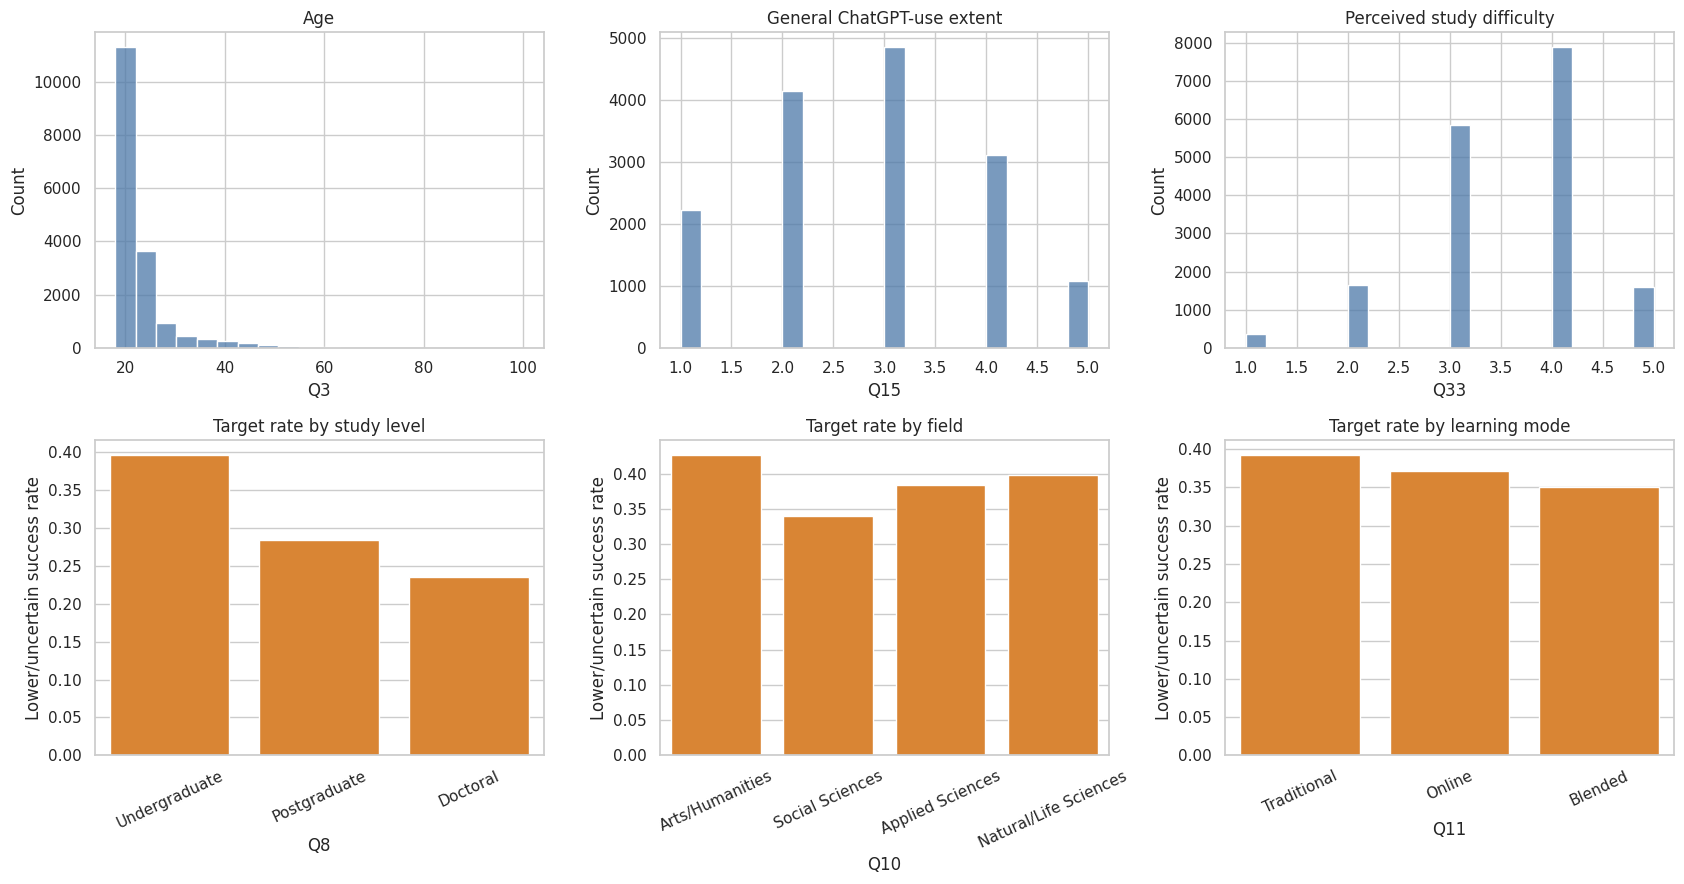

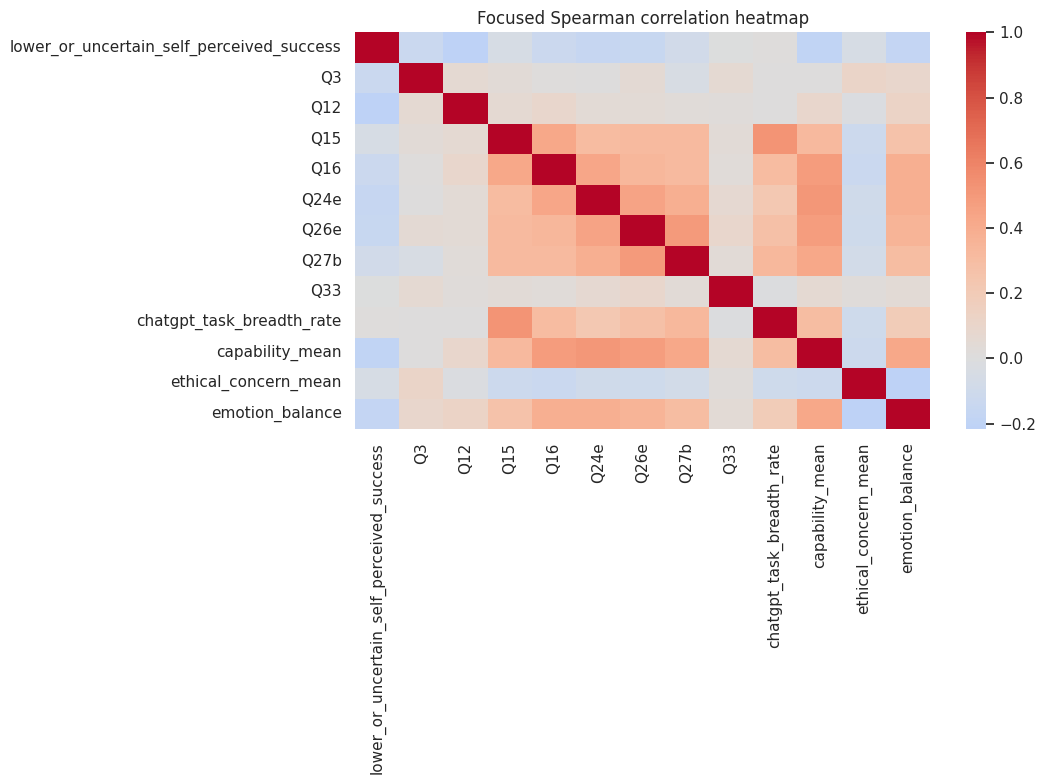

In [ ]:
## 2.5 Focused distributions, category relationships and correlations
study_level_labels = {1: "Undergraduate", 2: "Postgraduate", 3: "Doctoral"}
field_labels = {1: "Arts/Humanities", 2: "Social Sciences", 3: "Applied Sciences", 4: "Natural/Life Sciences"}
learning_labels = {1: "Traditional", 2: "Online", 3: "Blended"}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for axis, column, title in zip(
    axes[0],
    ["Q3", "Q15", "Q33"],
    ["Age", "General ChatGPT-use extent", "Perceived study difficulty"],
):
    sns.histplot(df_features[column], bins=20, kde=False, ax=axis, color="#4C78A8")
    axis.set_title(title)

for axis, column, labels, title in [
    (axes[1, 0], "Q8", study_level_labels, "Target rate by study level"),
    (axes[1, 1], "Q10", field_labels, "Target rate by field"),
    (axes[1, 2], "Q11", learning_labels, "Target rate by learning mode"),
]:
    grouped = df_features.groupby(column, observed=True)[TARGET_NAME].mean().rename(index=labels)
    sns.barplot(x=grouped.index.astype(str), y=grouped.values, ax=axis, color="#F58518")
    axis.set_ylabel("Lower/uncertain success rate")
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

correlation_columns = [
    TARGET_NAME,
    "Q3",
    "Q12",
    "Q15",
    "Q16",
    "Q24e",
    "Q26e",
    "Q27b",
    "Q33",
] + ENGINEERED_FEATURES
correlation_matrix = df_features[correlation_columns].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, square=False)
plt.title("Focused Spearman correlation heatmap")
plt.tight_layout()
plt.show()

### 2.5 Exploratory findings

The target is moderately imbalanced rather than rare: 37.0% of labelled respondents are in the lower/uncertain class. Unadjusted target rates vary across study level, field and learning mode, while related questionnaire constructs show substantial rank correlations. These patterns support composite construction and supervised feature selection, but they are descriptive and should not be interpreted as independent or causal effects.

In [ ]:
## 2.6 One locked stratified train/test split
train_indices, test_indices = train_test_split(
    X.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()
audit_test = audit_frame.loc[test_indices].copy()

assert set(train_indices).isdisjoint(set(test_indices))
assert len(X_train) + len(X_test) == len(X)
assert list(X_train.columns) == list(X_test.columns)
assert abs(y_train.mean() - y_test.mean()) < 0.01

split_summary = pd.DataFrame({
    "Rows": [len(X_train), len(X_test)],
    "Positive_count": [int(y_train.sum()), int(y_test.sum())],
    "Positive_rate": [float(y_train.mean()), float(y_test.mean())],
}, index=["Training", "Locked test"])
display(split_summary)

,Rows,Positive_count,Positive_rate
Training,13940,5164,0.370445
Locked test,3486,1291,0.370338


## 3. Model Development and Optimization

### 3.1 Leakage-controlled preprocessing

All learned operations are inside each model pipeline and are fitted independently within every cross-validation training fold:

- engineered continuous features: median imputation with missing indicators and RobustScaler;
- ordinal features: median imputation with missing indicators and StandardScaler;
- nominal features: an explicit Missing category and one-hot encoding;
- feature selection: ANOVA SelectPercentile, tuned only over 25%, 50% and 75%, so a genuine subset is always retained.

The fold-fitted selector is a computationally efficient supervised filter after encoding. Its limitation is that it detects univariate mean separation rather than feature interactions; nonlinear estimators can model interactions among the retained inputs.

The 37%/63% class split represents moderate imbalance. No synthetic resampling is applied; regularisation is tuned and class weighting is included for estimators that support it. Five fixed stratified folds provide comparable validation estimates, while six randomized candidates per family define a resource-conscious rather than exhaustive search.


In [ ]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(scale_numeric=True):
    continuous_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
    ordinal_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
    if scale_numeric:
        continuous_steps.append(("scaler", RobustScaler()))
        ordinal_steps.append(("scaler", StandardScaler()))

    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            ("continuous", Pipeline(continuous_steps), CONTINUOUS_COLUMNS),
            ("ordinal", Pipeline(ordinal_steps), ORDINAL_COLUMNS),
            ("nominal", nominal_pipeline, NOMINAL_COLUMNS),
        ],
        sparse_threshold=0,
        remainder="drop",
    )

def make_model_pipeline(estimator, scale_numeric=True):
    return Pipeline([
        ("preprocessor", make_preprocessor(scale_numeric=scale_numeric)),
        ("selector", SelectPercentile(score_func=f_classif, percentile=50)),
        ("model", estimator),
    ])

### 3.2 Compared model families

1. **Logistic Regression — linear:** interpretable regularised baseline with probabilities.
2. **K-Nearest Neighbours — distance-based:** tests local similarity after scaling.
3. **Random Forest — tree-based:** captures nonlinearities and interactions.
4. **Histogram Gradient Boosting — ensemble boosting:** efficient regularised boosted trees without an external runtime.
5. **MLPClassifier — artificial neural network:** two hidden layers test nonlinear representation learning without an additional deep-learning framework.

Each model uses the same training rows, the same materialized stratified folds, the same primary positive-class F1 objective and the same number of randomized-search trials.

In [ ]:
## 3.3 Model pipelines and compact hyperparameter spaces
model_specs = {
    "Logistic Regression": {
        "family": "Linear",
        "pipeline": make_model_pipeline(
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=True,
        ),
        "params": {
            "selector__percentile": [25, 50, 75],
            "model__C": [0.05, 0.2, 1.0, 5.0],
            "model__penalty": ["l1", "l2"],
            "model__class_weight": [None, "balanced"],
        },
    },
    "KNN": {
        "family": "Distance-based",
        "pipeline": make_model_pipeline(
            KNeighborsClassifier(n_jobs=1),
            scale_numeric=True,
        ),
        "params": {
            "selector__percentile": [25, 50, 75],
            "model__n_neighbors": [11, 21, 31, 51],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "Random Forest": {
        "family": "Tree-based",
        "pipeline": make_model_pipeline(
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            scale_numeric=False,
        ),
        "params": {
            "selector__percentile": [25, 50, 75],
            "model__n_estimators": [200, 350],
            "model__max_depth": [None, 12, 20],
            "model__min_samples_leaf": [1, 3, 6],
            "model__max_features": ["sqrt", 0.5],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Histogram Gradient Boosting": {
        "family": "Ensemble boosting",
        "pipeline": make_model_pipeline(
            HistGradientBoostingClassifier(
                loss="log_loss",
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=False,
        ),
        "params": {
            "selector__percentile": [25, 50, 75],
            "model__learning_rate": [0.03, 0.06, 0.10],
            "model__max_iter": [100, 180, 260],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [15, 30, 60],
            "model__l2_regularization": [0.0, 0.5, 2.0],
        },
    },
    "Artificial Neural Network": {
        "family": "Neural network",
        "pipeline": make_model_pipeline(
            MLPClassifier(
                max_iter=250,
                early_stopping=True,
                n_iter_no_change=12,
                random_state=RANDOM_STATE,
            ),
            scale_numeric=True,
        ),
        "params": {
            "selector__percentile": [25, 50, 75],
            "model__hidden_layer_sizes": [(64, 32), (96, 48), (128, 64)],
            "model__alpha": [0.0001, 0.001, 0.01],
            "model__learning_rate_init": [0.001, 0.003],
            "model__batch_size": [64, 128],
        },
    },
}

display(pd.DataFrame([
    {"Model": name, "Family": spec["family"], "Search_parameters": len(spec["params"])}
    for name, spec in model_specs.items()
]))

,Model,Family,Search_parameters
0,Logistic Regression,Linear,4
1,KNN,Distance-based,4
2,Random Forest,Tree-based,6
3,Histogram Gradient Boosting,Ensemble boosting,6
4,Artificial Neural Network,Neural network,5


In [ ]:
## 3.4 Common cross-validation folds, metrics and randomized search
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
COMMON_CV_SPLITS = list(cv.split(X_train, y_train))

SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

tuned_models = {}
cv_records = []

for model_name, spec in model_specs.items():
    print(f"Tuning {model_name}...")
    search = RandomizedSearchCV(
        estimator=spec["pipeline"],
        param_distributions=spec["params"],
        n_iter=SEARCH_ITERATIONS,
        scoring=SCORING,
        refit="f1",
        cv=COMMON_CV_SPLITS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
        verbose=1,
    )
    search.fit(X_train, y_train)

    best_index = search.best_index_
    record = {
        "Model": model_name,
        "Family": spec["family"],
        "CV_Accuracy": search.cv_results_["mean_test_accuracy"][best_index],
        "CV_Precision": search.cv_results_["mean_test_precision"][best_index],
        "CV_Recall": search.cv_results_["mean_test_recall"][best_index],
        "CV_F1": search.cv_results_["mean_test_f1"][best_index],
        "CV_F1_Std": search.cv_results_["std_test_f1"][best_index],
        "CV_ROC_AUC": search.cv_results_["mean_test_roc_auc"][best_index],
        "CV_PR_AUC": search.cv_results_["mean_test_pr_auc"][best_index],
        "Best_Params": search.best_params_,
    }
    cv_records.append(record)
    tuned_models[model_name] = search.best_estimator_

cv_results_df = (
    pd.DataFrame(cv_records)
    .sort_values("CV_F1", ascending=False)
    .reset_index(drop=True)
)
display(cv_results_df)

Tuning Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuning KNN...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuning Random Forest...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuning Histogram Gradient Boosting...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuning Artificial Neural Network...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


,Model,Family,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_F1_Std,CV_ROC_AUC,CV_PR_AUC,Best_Params
0,Logistic Regression,Linear,0.669082,0.543038,0.673124,0.601108,0.010685,0.723516,0.593552,"{'selector__percentile': 50, 'model__penalty':..."
1,Random Forest,Tree-based,0.692898,0.585577,0.584811,0.585032,0.014600,0.737335,0.627962,"{'selector__percentile': 25, 'model__n_estimat..."
2,Histogram Gradient Boosting,Ensemble boosting,0.709469,0.655584,0.455455,0.536994,0.016492,0.743675,0.647009,"{'selector__percentile': 50, 'model__min_sampl..."
3,Artificial Neural Network,Neural network,0.692611,0.613337,0.471528,0.531045,0.020083,0.719681,0.613167,"{'selector__percentile': 75, 'model__learning_..."
4,KNN,Distance-based,0.672740,0.569241,0.479082,0.520058,0.015528,0.690551,0.568453,"{'selector__percentile': 50, 'model__weights':..."


### 3.4 Cross-validation interpretation

Logistic Regression achieved the highest mean positive-class F1 (0.6011 ± 0.0107), supported by the highest recall (0.6731). Histogram Gradient Boosting produced the strongest ROC-AUC and PR-AUC but a lower recall of 0.4555, so it did not lead on the pre-specified F1 objective. The six-candidate searches are resource-conscious comparisons rather than exhaustive optimization; the saved table ellipsizes the parameter dictionaries, so no undisplayed hyperparameter value is inferred.

In [ ]:
## Select the deployment candidate using training CV only
selected_model_name = cv_results_df.loc[0, "Model"]
final_model = tuned_models[selected_model_name]

print("Selected by training CV:", selected_model_name)
display(cv_results_df.loc[[0], ["Model", "CV_F1", "CV_F1_Std", "Best_Params"]])


Selected by training CV: Logistic Regression


,Model,CV_F1,CV_F1_Std,Best_Params
0,Logistic Regression,0.601108,0.010685,"{'selector__percentile': 50, 'model__penalty':..."


In [ ]:
## Confirm that feature selection retained a genuine subset
final_preprocessor = final_model.named_steps["preprocessor"]
final_selector = final_model.named_steps["selector"]

transformed_feature_names = final_preprocessor.get_feature_names_out()
selection_mask = final_selector.get_support()
selected_feature_names = transformed_feature_names[selection_mask]
selected_feature_names_clean = [
    name.split("__", 1)[-1] for name in selected_feature_names
]

selection_summary = pd.Series({
    "Features after preprocessing": len(transformed_feature_names),
    "Features retained": len(selected_feature_names),
    "Retained percentage": 100 * len(selected_feature_names) / len(transformed_feature_names),
})
display(selection_summary.to_frame("Value"))
display(pd.DataFrame({"Selected_feature": selected_feature_names_clean}).head(20))
assert len(selected_feature_names) < len(transformed_feature_names)

,Value
Features after preprocessing,215.000000
Features retained,107.000000
Retained percentage,49.767442


,Selected_feature
0,capability_mean
1,ethical_concern_mean
2,emotion_balance
3,missingindicator_emotion_balance
4,Q12
5,Q13a
6,Q13b
7,Q13c
8,Q15
9,Q16


## 4. Performance Evaluation and Model Comparison

The five tuned estimators are evaluated on the locked holdout. The final candidate remains the model selected by training cross-validation; test results are not used to revise that decision. Accuracy, precision, recall, F1, ROC-AUC and PR-AUC are reported, with precision, recall and F1 defined for the positive class.

No asymmetric error cost is assumed in this exploratory analysis, so the default 0.50 decision threshold is retained and is not tuned on the test set.


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,CV_Rank
0,Logistic Regression,0.6546,0.5277,0.6429,0.5796,0.7124,0.5862,1
1,Random Forest,0.6799,0.5673,0.5716,0.5694,0.7209,0.6230,2
2,Histogram Gradient Boosting,0.7022,0.6365,0.4570,0.5320,0.7344,0.6337,3
3,Artificial Neural Network,0.6925,0.6435,0.3803,0.4781,0.7116,0.6050,4
4,KNN,0.6810,0.5833,0.4857,0.5300,0.6925,0.5779,5


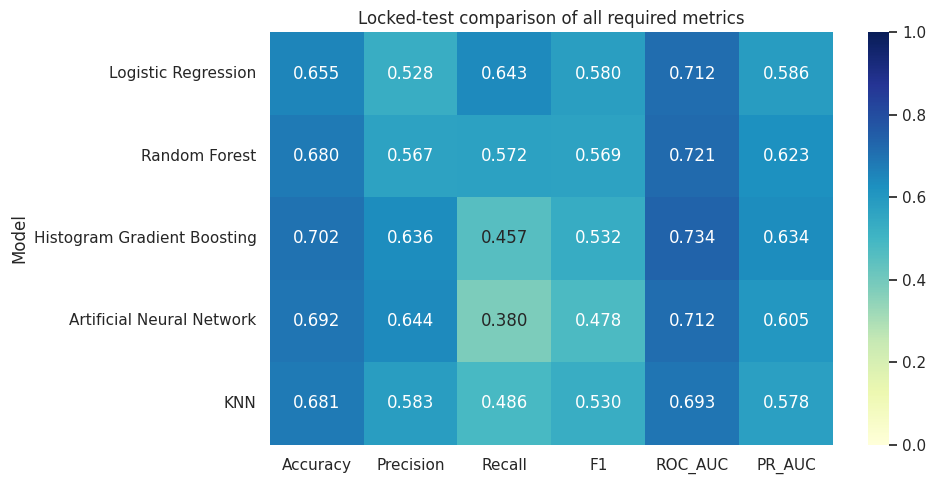

In [ ]:
## 4.1 Evaluate all five tuned models on the locked test set
test_records = []
prediction_store = {}

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    prediction_store[model_name] = {
        "prediction": y_pred,
        "probability": y_probability,
    }
    test_records.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_probability),
        "PR_AUC": average_precision_score(y_test, y_probability),
    })

test_results_df = pd.DataFrame(test_records)
test_results_df["CV_Rank"] = test_results_df["Model"].map(
    {name: rank + 1 for rank, name in enumerate(cv_results_df["Model"])}
)
test_results_df = test_results_df.sort_values("CV_Rank").reset_index(drop=True)

display(test_results_df.round(4))

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
plt.figure(figsize=(10, 5))
sns.heatmap(
    test_results_df.set_index("Model")[metrics],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)
plt.title("Locked-test performance across evaluation metrics")
plt.tight_layout()
plt.show()

### 4.2 Holdout comparison

The locked test set preserves the central trade-off. Logistic Regression has the highest positive-class recall (0.6429) and F1 (0.5796). Histogram Gradient Boosting has the highest accuracy (0.7022), ROC-AUC (0.7344) and PR-AUC (0.6337), but its recall is only 0.4570. The holdout results therefore describe generalization; they do not replace the model selected from training cross-validation.

Final model selected by CV: Logistic Regression
                                        precision    recall  f1-score   support

         Higher self-perceived success     0.7590    0.6615    0.7069      2195
Lower/uncertain self-perceived success     0.5277    0.6429    0.5796      1291

                              accuracy                         0.6546      3486
                             macro avg     0.6433    0.6522    0.6433      3486
                          weighted avg     0.6733    0.6546    0.6598      3486



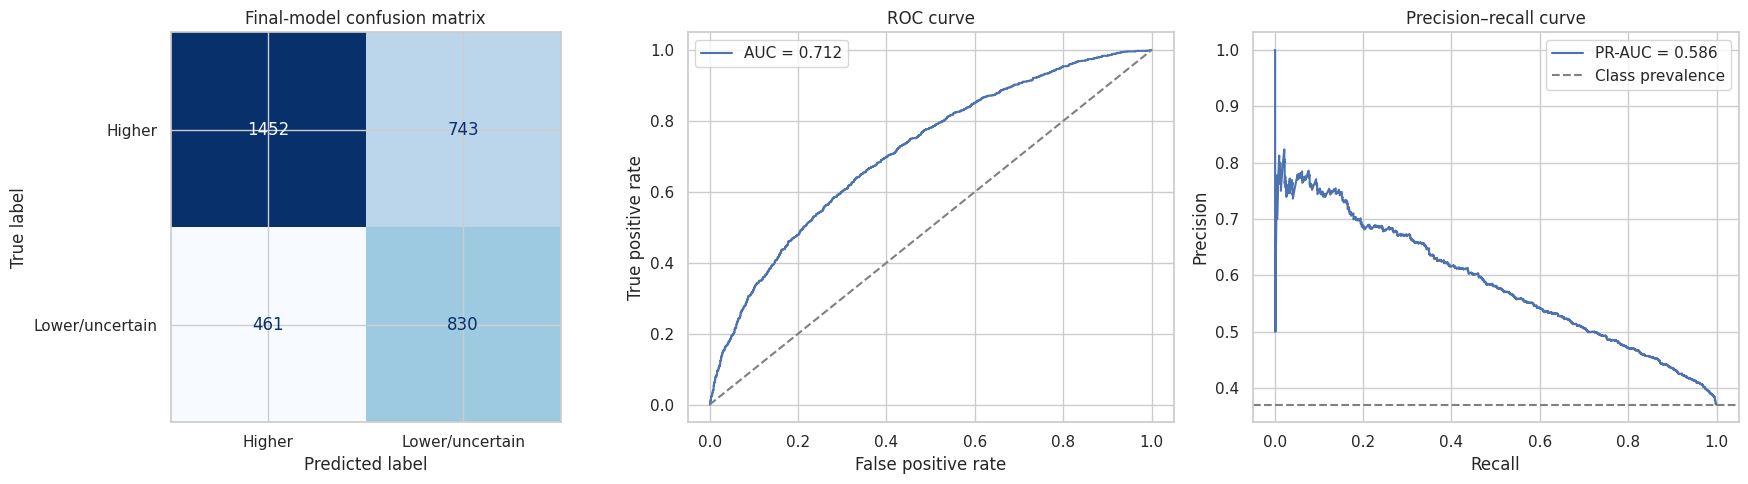

In [ ]:
## 4.2 Final-model classification report, confusion matrix, ROC and PR curves
final_prediction = prediction_store[selected_model_name]["prediction"]
final_probability = prediction_store[selected_model_name]["probability"]

print("Final model selected by CV:", selected_model_name)
print(classification_report(
    y_test,
    final_prediction,
    target_names=[
        "Higher self-perceived success",
        "Lower/uncertain self-perceived success",
    ],
    digits=4,
    zero_division=0,
))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_prediction,
    display_labels=["Higher", "Lower/uncertain"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Final-model confusion matrix")

fpr, tpr, _ = roc_curve(y_test, final_probability)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, final_probability):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

pr_precision, pr_recall, _ = precision_recall_curve(y_test, final_probability)
axes[2].plot(
    pr_recall,
    pr_precision,
    label=f"PR-AUC = {average_precision_score(y_test, final_probability):.3f}",
)
axes[2].axhline(y_test.mean(), linestyle="--", color="grey", label="Class prevalence")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision–recall curve")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
## 4.3 Detailed error analysis
error_analysis = X_test[["Q15", "Q16", "Q33"] + ENGINEERED_FEATURES].copy()
error_analysis.insert(0, "Q3_audit_only", audit_test["Q3"])
error_analysis["Actual"] = y_test
error_analysis["Predicted"] = final_prediction
error_analysis["Positive_probability"] = final_probability
error_analysis["Confidence"] = np.maximum(final_probability, 1 - final_probability)
error_analysis["Error_type"] = np.select(
    [
        (error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 0),
        (error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 1),
    ],
    ["False negative", "False positive"],
    default="Correct",
)

error_counts = error_analysis["Error_type"].value_counts().to_frame("Count")
error_counts["Percentage"] = 100 * error_counts["Count"] / len(error_analysis)
display(error_counts)

profile_columns = ["Q3_audit_only", "Q15", "Q16", "Q33"] + ENGINEERED_FEATURES + ["Confidence"]
error_profiles = (
    error_analysis
    .groupby("Error_type", observed=True)[profile_columns]
    .median()
    .round(3)
)
display(error_profiles)

high_confidence_errors = error_analysis[
    (error_analysis["Error_type"] != "Correct")
    & (error_analysis["Confidence"] >= 0.80)
]
print("High-confidence errors (confidence >= 0.80):", len(high_confidence_errors))
display(
    high_confidence_errors
    .sort_values("Confidence", ascending=False)
    .head(10)
)
print(
    "False negatives are missed positive-class cases and are reported separately. "
    "No asymmetric error cost was used for model selection."
)

,Count,Percentage
Error_type,,
Correct,2282,65.461847
False positive,743,21.313827
False negative,461,13.224326


,Q3_audit_only,Q15,Q16,Q33,chatgpt_task_breadth_rate,capability_mean,ethical_concern_mean,emotion_balance,Confidence
Error_type,,,,,,,,,
Correct,21.0,3.0,4.0,4.0,0.5,3.7,3.0,1.000,0.674
False negative,22.0,3.0,4.0,4.0,0.5,3.7,3.1,1.143,0.608
False positive,21.0,3.0,4.0,4.0,0.5,3.5,3.0,0.571,0.617


High-confidence errors (confidence >= 0.80): 73


,Q3_audit_only,Q15,Q16,Q33,chatgpt_task_breadth_rate,capability_mean,ethical_concern_mean,emotion_balance,Actual,Predicted,Positive_probability,Confidence,Error_type
18801,20,1.0,2.0,2.0,0.250000,2.4,1.000000,-0.285714,0,1,0.980477,0.980477,False positive
3933,19,1.0,1.0,4.0,0.000000,1.7,3.666667,-2.142857,0,1,0.972863,0.972863,False positive
18519,23,4.0,5.0,5.0,0.583333,5.0,4.000000,2.285714,1,0,0.037857,0.962143,False negative
18206,19,2.0,4.0,4.0,0.666667,3.1,2.700000,-1.571429,0,1,0.957014,0.957014,False positive
4976,18,2.0,4.0,3.0,0.583333,4.0,2.500000,2.428571,1,0,0.059830,0.940170,False negative
13847,18,1.0,4.0,3.0,0.083333,1.0,1.800000,1.571429,0,1,0.937248,0.937248,False positive
7013,21,2.0,2.0,3.0,0.500000,2.5,3.700000,-3.428571,0,1,0.928720,0.928720,False positive
9790,25,3.0,4.0,2.0,0.666667,1.0,5.000000,-0.571429,0,1,0.916834,0.916834,False positive
10248,24,4.0,5.0,4.0,1.000000,4.8,3.800000,1.142857,1,0,0.083929,0.916071,False negative
22641,20,4.0,5.0,3.0,0.916667,4.0,1.100000,2.452381,0,1,0.902494,0.902494,False positive


False negatives are missed positive-class cases and are reported separately. No asymmetric error cost was used for model selection.


In [ ]:
## 4.4 Technical and operational suitability
final_test_row = test_results_df.loc[
    test_results_df["Model"] == selected_model_name
].iloc[0]
final_cv_row = cv_results_df.loc[
    cv_results_df["Model"] == selected_model_name
].iloc[0]

technical_suitability = pd.Series({
    "Selected model": selected_model_name,
    "Selection basis": "Highest mean positive-class F1 in training CV",
    "CV F1 mean": final_cv_row["CV_F1"],
    "CV F1 standard deviation": final_cv_row["CV_F1_Std"],
    "Locked-test recall": final_test_row["Recall"],
    "Locked-test F1": final_test_row["F1"],
    "Locked-test PR-AUC": final_test_row["PR_AUC"],
    "Technical packaging": "Complete imputation, encoding, selection and estimator are serialized together",
    "Operational readiness": "No — exploratory research prototype only",
    "Prerequisites for operational use": "Shorter prospective inputs, objective outcome, external validation and human governance",
})
display(technical_suitability.to_frame("Evidence"))

algorithm_suitability = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Production strengths": "Small, fast, stable probabilities and relatively transparent coefficients",
        "Production concern": "May miss nonlinear relationships",
    },
    {
        "Model": "KNN",
        "Production strengths": "Simple local-similarity benchmark",
        "Production concern": "Stores training data and has slower inference and greater privacy/memory burden",
    },
    {
        "Model": "Random Forest",
        "Production strengths": "Robust nonlinear model with parallel prediction",
        "Production concern": "Larger artifact and less transparent than a linear model",
    },
    {
        "Model": "Histogram Gradient Boosting",
        "Production strengths": "Efficient nonlinear tabular model with regularisation",
        "Production concern": "Requires drift monitoring and is less transparent than a linear model",
    },
    {
        "Model": "Artificial Neural Network",
        "Production strengths": "Flexible nonlinear decision function",
        "Production concern": "Harder to explain and tune; may offer no benefit on medium-sized tabular data",
    },
])
display(algorithm_suitability)


,Evidence
Selected model,Logistic Regression
Selection basis,Highest mean positive-class F1 in training CV
CV F1 mean,0.601108
CV F1 standard deviation,0.010685
Locked-test recall,0.642912
Locked-test F1,0.579609
Locked-test PR-AUC,0.586212
Technical packaging,"Complete imputation, encoding, selection and e..."
Operational readiness,No — exploratory research prototype only
Prerequisites for operational use,"Shorter prospective inputs, objective outcome,..."


,Model,Production strengths,Production concern
0,Logistic Regression,"Small, fast, stable probabilities and relative...",May miss nonlinear relationships
1,KNN,Simple local-similarity benchmark,Stores training data and has slower inference ...
2,Random Forest,Robust nonlinear model with parallel prediction,Larger artifact and less transparent than a li...
3,Histogram Gradient Boosting,Efficient nonlinear tabular model with regular...,Requires drift monitoring and is less transpar...
4,Artificial Neural Network,Flexible nonlinear decision function,Harder to explain and tune; may offer no benef...


## 5. Explainability, Fairness and Ethical Considerations

- **Global influence:** model-agnostic permutation importance measures the decrease in test F1 when each original model input is shuffled.
- **Decision behaviour:** partial dependence estimates isolated average model response, while observed probability-by-bin summaries retain correlations with other inputs.
- These views describe fitted behaviour and association, not causation; disagreement between them is informative rather than contradictory.
- Fairness is audited separately by gender, age band and survey language. None is used as a model input.


Explanation sample rows: 1200


,Feature,Importance_mean,Importance_std
0,Q12,0.051281,0.001466
1,Q9,0.018920,0.006763
2,emotion_balance,0.013502,0.008106
3,Q10,0.009784,0.002651
4,Q25a,0.009098,0.003491
5,Q30j,0.008695,0.002174
6,Q17,0.008614,0.002448
7,Q28b,0.007910,0.002695
8,Q24b,0.007534,0.003489
9,Q30b,0.006676,0.004573


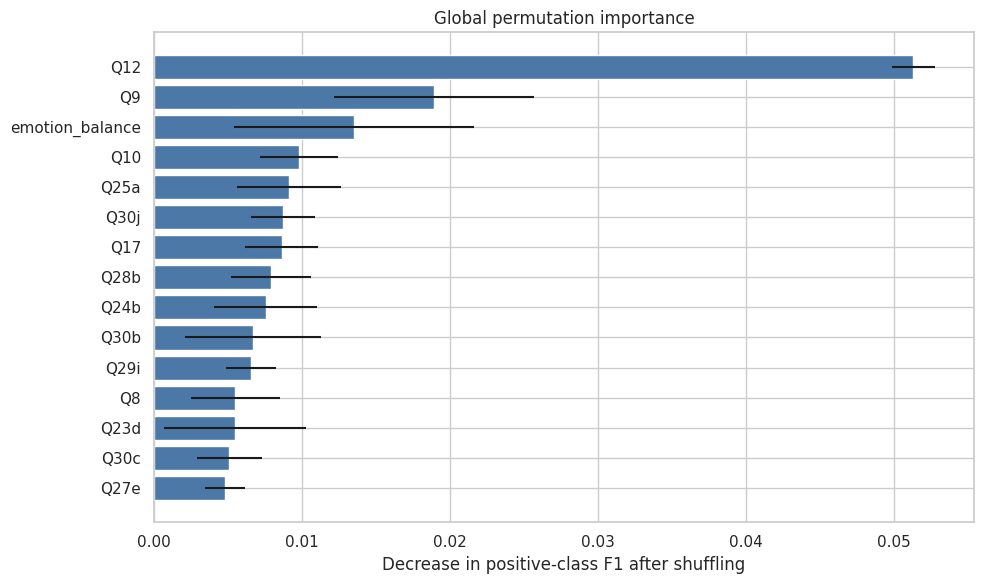

In [ ]:
## 5.1 Global permutation importance on a fixed explanation sample
if len(X_test) > 1200:
    _, explanation_indices = train_test_split(
        X_test.index,
        test_size=1200,
        random_state=RANDOM_STATE,
        stratify=y_test,
    )
else:
    explanation_indices = X_test.index

X_explain = X_test.loc[explanation_indices]
y_explain = y_test.loc[explanation_indices]

permutation = permutation_importance(
    final_model,
    X_explain,
    y_explain,
    scoring="f1",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = (
    pd.DataFrame({
        "Feature": X_explain.columns,
        "Importance_mean": permutation.importances_mean,
        "Importance_std": permutation.importances_std,
    })
    .sort_values("Importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("Explanation sample rows:", len(X_explain))
display(permutation_df.head(15))

plt.figure(figsize=(10, 6))
top_permutation = permutation_df.head(15).sort_values("Importance_mean")
plt.barh(
    top_permutation["Feature"],
    top_permutation["Importance_mean"],
    xerr=top_permutation["Importance_std"],
    color="#4C78A8",
)
plt.xlabel("Decrease in positive-class F1 after shuffling")
plt.title("Global permutation importance")
plt.tight_layout()
plt.show()


### 5.2 Explanation of global influence

The largest permutation effects are Q12 (confidence about obtaining a job after study), Q9 (first-year Bachelor's status) and `emotion_balance`. Importance is measured as the decrease in positive-class F1 after shuffling. It reflects predictive dependence in this fitted pipeline, may be shared or diluted among correlated questionnaire items, and does not establish that an input causes the outcome.

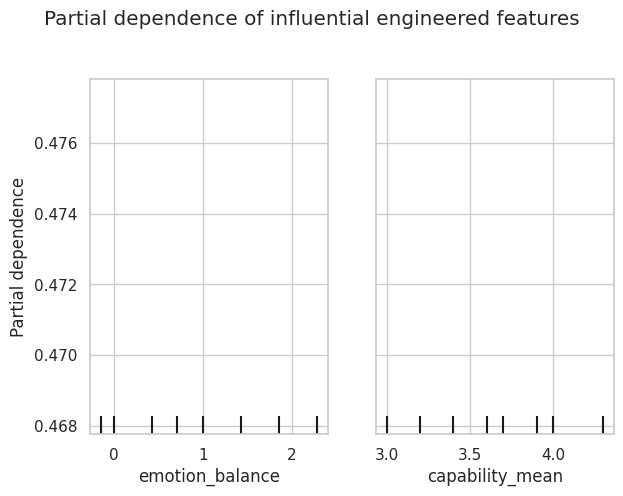

,N,Median_feature_value,Actual_positive_rate,Mean_predicted_probability
Feature_bin,,,,
"(-4.001, 0.0]",756,-0.142857,0.492063,0.581431
"(0.0, 0.571]",483,0.285714,0.436853,0.538628
"(0.571, 1.143]",637,0.857143,0.334380,0.474404
"(1.143, 1.857]",624,1.571429,0.328526,0.423575
"(1.857, 4.0]",594,2.428571,0.249158,0.355334


Partial dependence varies one feature while averaging predictions over the explanation sample; it describes the fitted model, not a causal effect.


In [ ]:
## 5.2 Directional decision behaviour for influential engineered features
top_numeric_features = (
    permutation_df.loc[
        permutation_df["Feature"].isin(CONTINUOUS_COLUMNS),
        "Feature",
    ]
    .head(2)
    .tolist()
)
if not top_numeric_features:
    top_numeric_features = CONTINUOUS_COLUMNS[:2]

pdp = PartialDependenceDisplay.from_estimator(
    final_model,
    X_explain,
    features=top_numeric_features,
    kind="average",
    grid_resolution=20,
)
pdp.figure_.suptitle("Partial dependence of influential engineered features", y=1.03)
plt.tight_layout()
plt.show()

decision_feature = top_numeric_features[0]
decision_table = pd.DataFrame({
    decision_feature: X_test[decision_feature],
    "Actual": y_test,
    "Predicted_probability": final_probability,
}).dropna(subset=[decision_feature])
decision_table["Feature_bin"] = pd.qcut(
    decision_table[decision_feature],
    q=5,
    duplicates="drop",
)
decision_summary = (
    decision_table
    .groupby("Feature_bin", observed=True)
    .agg(
        N=("Actual", "size"),
        Median_feature_value=(decision_feature, "median"),
        Actual_positive_rate=("Actual", "mean"),
        Mean_predicted_probability=("Predicted_probability", "mean"),
    )
)
display(decision_summary)
print(
    "Partial dependence varies one feature while averaging predictions over the explanation sample; "
    "it describes the fitted model, not a causal effect."
)


### 5.3 Directional interpretation

The saved partial-dependence curves are approximately flat, so they do not support a strong isolated marginal effect for the displayed composites. The observed emotion-balance bins show a different descriptive pattern: the actual positive rate falls from 0.492 to 0.249 and mean predicted probability from 0.581 to 0.355 across the lowest-to-highest bins. Because other correlated inputs vary across these bins, this is an association rather than a causal or isolated feature effect.

In [ ]:
## 5.3 Compact subgroup fairness audit
gender_labels = {
    1: "Male",
    2: "Female",
    3: "Other",
    4: "Prefer not to say",
}
gender_group = audit_test["Q2"].map(gender_labels).fillna("Missing")
age_group = pd.cut(
    audit_test["Q3"],
    bins=[17, 21, 24, 29, 39, 100],
    labels=["18–21", "22–24", "25–29", "30–39", "40+"],
).astype(object)
age_group = pd.Series(age_group, index=audit_test.index).fillna("Missing")
language_group = audit_test["source"].astype("string").fillna("Missing")

def subgroup_metrics(attribute_name, groups, minimum_size=100, minimum_class_count=30):
    rows = []
    y_true_array = y_test.to_numpy()
    group_array = pd.Series(groups).to_numpy()
    for group_name in pd.Series(groups).dropna().unique():
        mask = group_array == group_name
        n = int(mask.sum())
        actual = y_true_array[mask]
        predicted = final_prediction[mask]
        tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
        positive_n = int(tp + fn)
        negative_n = int(tn + fp)
        supported = (
            n >= minimum_size
            and positive_n >= minimum_class_count
            and negative_n >= minimum_class_count
        )
        rows.append({
            "Attribute": attribute_name,
            "Group": group_name,
            "N": n,
            "Actual_positive_N": positive_n,
            "Actual_negative_N": negative_n,
            "Actual_positive_rate": actual.mean() if supported else np.nan,
            "Predicted_positive_rate": predicted.mean() if supported else np.nan,
            "Accuracy": accuracy_score(actual, predicted) if supported else np.nan,
            "Precision": precision_score(actual, predicted, zero_division=0) if supported else np.nan,
            "TPR_Recall": tp / (tp + fn) if supported else np.nan,
            "FPR": fp / (fp + tn) if supported else np.nan,
            "Interpretation_status": (
                "Reported"
                if supported
                else "Suppressed: insufficient total or class-specific N"
            ),
        })
    return rows

fairness_rows = (
    subgroup_metrics("Gender", gender_group)
    + subgroup_metrics("Age band", age_group)
    + subgroup_metrics("Survey language", language_group)
)
fairness_df = pd.DataFrame(fairness_rows).sort_values(["Attribute", "Group"])
display(fairness_df)

supported_fairness = fairness_df[
    fairness_df["Interpretation_status"] == "Reported"
]
fairness_gap_df = (
    supported_fairness
    .groupby("Attribute", observed=True)
    .agg(
        Supported_groups=("Group", "nunique"),
        TPR_gap=("TPR_Recall", lambda values: values.max() - values.min()),
        FPR_gap=("FPR", lambda values: values.max() - values.min()),
        Predicted_positive_rate_gap=(
            "Predicted_positive_rate",
            lambda values: values.max() - values.min(),
        ),
    )
    .reset_index()
)
display(fairness_gap_df)
print(
    "These descriptive gaps can reflect sampling, translation, geography, construct and model effects; "
    "they are not proof of discrimination or fairness."
)


,Attribute,Group,N,Actual_positive_N,Actual_negative_N,Actual_positive_rate,Predicted_positive_rate,Accuracy,Precision,TPR_Recall,FPR,Interpretation_status
7,Age band,18–21,1854,750,1104,0.404531,0.527508,0.641855,0.543967,0.709333,0.403986,Reported
6,Age band,22–24,925,330,595,0.356757,0.430270,0.654054,0.512563,0.618182,0.326050,Reported
5,Age band,25–29,377,135,242,0.358090,0.307692,0.668435,0.543103,0.466667,0.219008,Reported
8,Age band,30–39,186,45,141,0.241935,0.268817,0.704301,0.400000,0.444444,0.212766,Reported
9,Age band,40+,133,27,106,NaN,NaN,NaN,NaN,NaN,NaN,Suppressed: insufficient total or class-specif...
10,Age band,Missing,11,4,7,NaN,NaN,NaN,NaN,NaN,NaN,Suppressed: insufficient total or class-specif...
0,Gender,Female,2102,728,1374,0.346337,0.450999,0.659372,0.506329,0.659341,0.340611,Reported
1,Gender,Male,1336,540,796,0.404192,0.448353,0.647455,0.557596,0.618519,0.332915,Reported
2,Gender,Missing,15,7,8,NaN,NaN,NaN,NaN,NaN,NaN,Suppressed: insufficient total or class-specif...
4,Gender,Other,10,2,8,NaN,NaN,NaN,NaN,NaN,NaN,Suppressed: insufficient total or class-specif...


,Attribute,Supported_groups,TPR_gap,FPR_gap,Predicted_positive_rate_gap
0,Age band,4,0.264889,0.191220,0.258691
1,Gender,2,0.040822,0.007697,0.002646
2,Survey language,5,0.242770,0.210934,0.198669


These descriptive gaps can reflect sampling, translation, geography, construct and model effects; they are not proof of discrimination or fairness.


### 5.4 Subgroup interpretation

Supported male and female groups have comparatively small gaps (TPR 0.0408; FPR 0.0077). Age-band gaps (TPR 0.2649; FPR 0.1912) and survey-language gaps (TPR 0.2428; FPR 0.2109) are materially larger. They may reflect sampling, geography, translation and construct differences rather than discrimination alone, but they are large enough to block operational use pending representative validation and subgroup-specific investigation.

### 5.4 Fairness, privacy and ethical limits

- The survey used convenience sampling; countries, languages and institutions are not proportionally representative.
- The target and predictors are subjective and cross-sectional. Predictions are associative, not causal.
- Questionnaire routing creates structurally non-random missingness, and excluding 5,410 records with no target after deduplication may introduce selection bias.
- Gender, age, citizenship, study country, institution, free text and survey language are excluded from prediction. Gender, age band and survey language are used only for auditing.
- Small or class-sparse subgroup estimates are suppressed. The supported age and survey-language groups show substantial error-rate gaps, which preclude deployment claims until representative external validation, translation review and subgroup-specific error investigation are completed.
- Predictions must not be used to grade, discipline, diagnose or restrict opportunities.
- Asking Q35a directly is more transparent than inferring it from a long survey; the current application is therefore an exploratory research prototype.
- Any future support use should be voluntary, human reviewed and offer a route to question decisions.
- Store the minimum data required, encrypt it in transit and at rest, restrict access, avoid raw payloads in logs and apply retention limits.
- A shorter prospective design, an objective outcome and external validation would be required before operational use.


## 6. Cloud Deployment and MLOps Strategy

### 6.1 One coherent GCP design

Raw survey data → API validation and the same four engineered features → authenticated FastAPI container on Cloud Run → probability, class and model version. Real-time requests use POST /predict. Large scheduled cohorts use a Cloud Run Job reading versioned inputs from Cloud Storage and writing pseudonymous results to BigQuery.

| Lifecycle concern | GCP design and justification |
|---|---|
| Storage and data versioning | Versioned Cloud Storage paths retain raw/processed references, questionnaire, DOI and checksum; BigQuery supports governed batch outputs. |
| Experiment and model versioning | Vertex AI Experiments records folds, parameters and metrics; Vertex AI Model Registry provides lineage, approved versions and rollback aliases. |
| Packaging, serving and scalability | A Docker image in Artifact Registry gives identical horizontal replicas; private Cloud Run suits sporadic low-latency traffic through autoscaling and scale-to-zero. |
| Security | IAM least privilege, dedicated service accounts, Secret Manager, encryption and audit logs; no public endpoint and no direct identifiers. |
| CI/CD and testing | Git + Cloud Build run schema, feature-engineering, prediction and API tests; build the image; deploy a new revision; smoke-test; then promote or roll back. |
| Monitoring, logging and alerts | Cloud Logging/Monitoring track errors and latency. Scheduled checks cover schema, missingness, feature and prediction drift; delayed Q35a labels enable performance, fairness and concept-drift checks. Alert policies notify the responsible MLOps support channel. |
| Retraining and updates | Termly or drift-triggered Vertex AI Pipeline → validation → training CV → performance/fairness gates → human approval → registry promotion → staged deployment and rollback. |

Managed GCP storage, build, registry and monitoring services provide a coherent lifecycle without introducing cluster administration. This is a proposed design, not a claim that live cloud resources have been provisioned.


In [ ]:
## 6.2 Package the model and generate a validated container/API design
if ARTIFACT_DIR.exists():
    shutil.rmtree(ARTIFACT_DIR)
ARTIFACT_DIR.mkdir(parents=True)

model_path = ARTIFACT_DIR / "model.joblib"
joblib.dump(final_model, model_path)

class_labels = {
    "0": "Higher self-perceived success",
    "1": "Lower/uncertain self-perceived success",
}
selected_parameters = cv_results_df.loc[0, "Best_Params"]

metadata = {
    "model_version": "q1-v1",
    "dataset_title": DATASET_TITLE,
    "dataset_doi": DATASET_DOI,
    "dataset_version": 2,
    "dataset_zip_sha256": dataset_zip_sha256,
    "target_source": TARGET_SOURCE,
    "target_name": TARGET_NAME,
    "class_labels": class_labels,
    "positive_class": 1,
    "selected_model": selected_model_name,
    "selected_hyperparameters": selected_parameters,
    "selection_metric": "training cross-validated positive-class F1",
    "cv_folds": CV_FOLDS,
    "random_state": RANDOM_STATE,
    "decision_threshold": 0.50,
    "runtime_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
    "test_metrics": {
        key: float(final_test_row[key])
        for key in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
    },
    "intended_use": "Coursework proof-of-concept associative classification",
    "limitations": [
        "Self-perceived rather than objective academic success",
        "Cross-sectional convenience sample",
        "Structurally non-random questionnaire missingness",
        "No causal interpretation or automated academic decision-making",
    ],
}
(ARTIFACT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

RAW_MODEL_FEATURES = [
    column for column in MODEL_FEATURE_COLUMNS
    if column not in ENGINEERED_FEATURES
]
RAW_API_FEATURES = list(dict.fromkeys(
    RAW_MODEL_FEATURES
    + TASK_COLUMNS
    + CAPABILITY_COLUMNS
    + ETHICAL_COLUMNS
    + POSITIVE_EMOTIONS
    + NEGATIVE_EMOTIONS
))
API_RANGE_RULES = {
    column: [lower, upper]
    for column, (lower, upper) in range_rules.items()
    if column in RAW_API_FEATURES
}

feature_schema = {
    "input_stage": "Validated raw Q6-Q34 questionnaire fields; protected audit fields are excluded",
    "raw_api_features": RAW_API_FEATURES,
    "model_feature_names": MODEL_FEATURE_COLUMNS,
    "nominal_features": NOMINAL_COLUMNS,
    "minimum_non_missing_raw_fields": 10,
    "range_rules": API_RANGE_RULES,
    "engineered_features": {
        "chatgpt_task_breadth_rate": {
            "source_columns": TASK_COLUMNS,
            "minimum_answered": 10,
            "calculation": "Proportion of answered values >= 3",
        },
        "capability_mean": {
            "source_columns": CAPABILITY_COLUMNS,
            "minimum_answered": 8,
            "calculation": "Mean",
        },
        "ethical_concern_mean": {
            "source_columns": ETHICAL_COLUMNS,
            "minimum_answered": 8,
            "calculation": "Mean",
        },
        "emotion_balance": {
            "positive_columns": POSITIVE_EMOTIONS,
            "negative_columns": NEGATIVE_EMOTIONS,
            "minimum_positive_answered": 6,
            "minimum_negative_answered": 6,
            "calculation": "Positive mean minus negative mean",
        },
    },
}
(ARTIFACT_DIR / "feature_schema.json").write_text(
    json.dumps(feature_schema, indent=2),
    encoding="utf-8",
)

raw_feature_names = feature_schema["raw_api_features"]
model_feature_names = feature_schema["model_feature_names"]
nominal_features = feature_schema["nominal_features"]
api_range_rules = feature_schema["range_rules"]
minimum_non_missing_raw_fields = feature_schema["minimum_non_missing_raw_fields"]
engineered_feature_rules = feature_schema["engineered_features"]

preparation_code = r"""
def api_row_mean(frame, columns, minimum_answered):
    block = frame[columns].apply(pd.to_numeric, errors="coerce")
    answered = block.notna().sum(axis=1)
    return block.mean(axis=1, skipna=True).where(answered >= minimum_answered)

def engineer_model_features(frame):
    result = frame.copy()
    task_rule = engineered_feature_rules["chatgpt_task_breadth_rate"]
    task_block = result[task_rule["source_columns"]].apply(
        pd.to_numeric, errors="coerce"
    )
    task_answered = task_block.notna().sum(axis=1)
    result["chatgpt_task_breadth_rate"] = (
        task_block.ge(3).sum(axis=1)
        .div(task_answered.replace(0, np.nan))
        .where(task_answered >= task_rule["minimum_answered"])
    )

    capability_rule = engineered_feature_rules["capability_mean"]
    result["capability_mean"] = api_row_mean(
        result,
        capability_rule["source_columns"],
        capability_rule["minimum_answered"],
    )

    ethical_rule = engineered_feature_rules["ethical_concern_mean"]
    result["ethical_concern_mean"] = api_row_mean(
        result,
        ethical_rule["source_columns"],
        ethical_rule["minimum_answered"],
    )

    emotion_rule = engineered_feature_rules["emotion_balance"]
    result["emotion_balance"] = (
        api_row_mean(
            result,
            emotion_rule["positive_columns"],
            emotion_rule["minimum_positive_answered"],
        )
        - api_row_mean(
            result,
            emotion_rule["negative_columns"],
            emotion_rule["minimum_negative_answered"],
        )
    )
    return result

def normalize_nominal(value):
    if pd.isna(value):
        return np.nan
    return str(int(float(value)))

def prepare_api_records(records):
    if not records or any(not isinstance(record, dict) or not record for record in records):
        raise ValueError("Each request must contain a non-empty feature dictionary.")

    unknown = sorted(set().union(*(record.keys() for record in records)) - set(raw_feature_names))
    if unknown:
        raise ValueError(f"Unknown questionnaire fields: {unknown}")

    frame = pd.DataFrame(records).reindex(columns=raw_feature_names)
    for column in raw_feature_names:
        original = frame[column]
        numeric = pd.to_numeric(original, errors="coerce")
        if (original.notna() & numeric.isna()).any():
            raise ValueError(f"{column} contains a non-numeric value.")
        frame[column] = numeric

    for column, bounds in api_range_rules.items():
        lower, upper = bounds
        invalid = frame[column].notna() & (
            ~frame[column].between(lower, upper)
            | (frame[column] % 1 != 0)
        )
        if invalid.any():
            raise ValueError(
                f"{column} must contain an integer from {lower} to {upper}."
            )

    coverage = frame.notna().sum(axis=1)
    if (coverage < minimum_non_missing_raw_fields).any():
        raise ValueError(
            f"At least {minimum_non_missing_raw_fields} recognised raw fields are required."
        )

    engineered = engineer_model_features(frame)
    model_frame = engineered.reindex(columns=model_feature_names)
    for column in nominal_features:
        model_frame[column] = model_frame[column].map(normalize_nominal).astype(object)
    return model_frame
"""
exec(preparation_code, globals())

app_header = """from pathlib import Path
from typing import Any
import json

import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

BASE_DIR = Path(__file__).resolve().parent
model = joblib.load(BASE_DIR / "model.joblib")
metadata = json.loads((BASE_DIR / "metadata.json").read_text())
schema = json.loads((BASE_DIR / "feature_schema.json").read_text())
raw_feature_names = schema["raw_api_features"]
model_feature_names = schema["model_feature_names"]
nominal_features = schema["nominal_features"]
api_range_rules = schema["range_rules"]
minimum_non_missing_raw_fields = schema["minimum_non_missing_raw_fields"]
engineered_feature_rules = schema["engineered_features"]

app = FastAPI(title="Q1 Associative Classification API", version="1.0")

class PredictionRequest(BaseModel):
    features: dict[str, Any]
"""

app_footer = """
def score(records):
    frame = prepare_api_records(records)
    probabilities = model.predict_proba(frame)[:, 1]
    threshold = metadata["decision_threshold"]
    predictions = (probabilities >= threshold).astype(int)
    return [
        {
            "prediction": metadata["class_labels"][str(int(prediction))],
            "positive_class_probability": float(probability),
            "model_version": metadata["model_version"],
        }
        for prediction, probability in zip(predictions, probabilities)
    ]

@app.get("/health")
def health():
    return {"status": "ok"}

@app.get("/model-info")
def model_info():
    return metadata

@app.post("/predict")
def predict(request: PredictionRequest):
    try:
        return score([request.features])[0]
    except ValueError as error:
        raise HTTPException(status_code=422, detail=str(error)) from error
"""

app_code = app_header + preparation_code + app_footer
(ARTIFACT_DIR / "app.py").write_text(app_code, encoding="utf-8")

requirements_text = f"""numpy=={np.__version__}
pandas=={pd.__version__}
scikit-learn=={sklearn.__version__}
joblib=={joblib.__version__}
fastapi>=0.110,<1
uvicorn[standard]>=0.29,<1
"""
(ARTIFACT_DIR / "requirements.txt").write_text(requirements_text, encoding="utf-8")

python_minor = ".".join(platform.python_version().split(".")[:2])
dockerfile_text = f"""FROM python:{python_minor}-slim
WORKDIR /app
COPY . /app
RUN pip install --no-cache-dir -r requirements.txt
ENV PORT=8080
CMD ["sh", "-c", "uvicorn app:app --host 0.0.0.0 --port $PORT"]
"""
(ARTIFACT_DIR / "Dockerfile").write_text(dockerfile_text, encoding="utf-8")

api_contract = {
    "GET /health": "Service health",
    "GET /model-info": "Model, data version, metrics and intended use",
    "POST /predict": "One validated raw questionnaire record for real-time inference",
    "Batch path": "Cloud Run Job over versioned Cloud Storage inputs",
}
(ARTIFACT_DIR / "api_contract.json").write_text(
    json.dumps(api_contract, indent=2),
    encoding="utf-8",
)

print("Model package directory:", ARTIFACT_DIR.resolve())


Model package directory: /content/q1_model_package


In [ ]:
## 6.3 Reload and raw-input serving smoke tests
compile(
    (ARTIFACT_DIR / "app.py").read_text(encoding="utf-8"),
    str(ARTIFACT_DIR / "app.py"),
    "exec",
)

reloaded_model = joblib.load(ARTIFACT_DIR / "model.joblib")
original_smoke_probability = final_model.predict_proba(X_test.head(25))[:, 1]
reloaded_smoke_probability = reloaded_model.predict_proba(X_test.head(25))[:, 1]
assert np.allclose(original_smoke_probability, reloaded_smoke_probability)

raw_smoke_records = (
    df_features
    .loc[X_test.index[:1], RAW_API_FEATURES]
    .to_dict(orient="records")
)
prepared_smoke = prepare_api_records(raw_smoke_records)
expected_smoke = X_test.head(1).reset_index(drop=True)
pd.testing.assert_frame_equal(
    prepared_smoke.reset_index(drop=True),
    expected_smoke,
    check_dtype=False,
)

service_probability = reloaded_model.predict_proba(prepared_smoke)[:, 1]
expected_probability = final_model.predict_proba(X_test.head(1))[:, 1]
assert np.allclose(service_probability, expected_probability)

artifact_table = pd.DataFrame([
    {
        "File": item.name,
        "Bytes": item.stat().st_size,
        "SHA256": sha256_file(item),
    }
    for item in sorted(ARTIFACT_DIR.iterdir())
    if item.is_file()
])
display(artifact_table)

print("Reload test passed: probabilities are identical.")
print("Raw-input test passed: validation and four engineered features reproduce training input.")


,File,Bytes,SHA256
0,Dockerfile,176,a291ea8f76bbd59f85b582c2e7b51131c97bbdf451baa6...
1,api_contract.json,261,318ad7bc06b086ba718cc41700277b48d819a201c91273...
2,app.py,5068,51037678a0d384e0ad8c1c0a53b7f75dbcff8b7b6dcfba...
3,feature_schema.json,9957,489d9e94b52dd74dafb578c868368fba84d0531a68273b...
4,metadata.json,1547,c3ff7370f38262d6827270c1fce18367bb0436e40e771f...
5,model.joblib,19734,92b02805f058a37ba3c217d5c6e9aa723d4a563f31b799...
6,requirements.txt,106,79c198d76575b554fb0d6b0cf56feee6c7223e26cb9b00...


Reload test passed: probabilities are identical.
Raw-input test passed: validation and four engineered features reproduce training input.


### 6.4 Validation status

The notebook generated the serialized pipeline, schema, metadata, FastAPI source, dependency specification, Dockerfile and API contract. Source compilation, model reload, raw-input validation, feature reproduction and probability equivalence passed. The Docker image and HTTP endpoints were not exercised, and no GCP resource was provisioned; Cloud Run and the surrounding managed services remain a deployment design rather than a live system.